# EDA — Clasificación de Autoría de Modelos de IA
**Asignatura:** Unstructured Data Analysis  
**Objetivo:** Análisis exploratorio del dataset de textos generados por 5 LLMs para identificar huellas estilísticas discriminatorias.

**Modelos objetivo:**
- `x-ai/grok-3-mini`
- `openai/gpt-4.1-nano`
- `mistralai/mixtral-8x7b-instruct`
- `meta-llama/llama-3.2-1b-instruct`
- `google/gemini-2.5-flash-lite`

**Pipeline del EDA:**
1. Setup e imports
2. Carga del dataset
3. Distribución de clases
4. Análisis de longitud y tokens
5. Riqueza léxica (TTR)
6. Frecuencias y n-gramas
7. WordClouds
8. Rasgos estilométricos (conectores + tags estructurales)
9. N-gramas discriminatorios (TF-IDF one-vs-rest)
10. Reducción dimensional (LSA 2D)
11. Resumen de fingerprints
12. Conclusiones

---
## 0. Setup e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD

try:
    from wordcloud import WordCloud
    WORDCLOUD_OK = True
except ImportError:
    WORDCLOUD_OK = False
    print("WordCloud no instalada: pip install wordcloud")

warnings.filterwarnings('ignore')

# ── Stopwords extendidas (inglés + tags estructurales) ─────────────────────
TAGS         = {'boldtag', 'newlinetag', 'bullettag', 'numlisttag'}
STOPWORDS_WC = ENGLISH_STOP_WORDS | TAGS          # para WordCloud
STOPWORDS_SK = list(ENGLISH_STOP_WORDS | TAGS)    # para sklearn (necesita list)

# ── Paleta por modelo (consistente en todas las gráficas) ─────────────────
MODEL_COLORS = {
    'x-ai/grok-3-mini':                 '#6366f1',
    'openai/gpt-4.1-nano':              '#f59e0b',
    'mistralai/mixtral-8x7b-instruct':  '#10b981',
    'meta-llama/llama-3.2-1b-instruct': '#ef4444',
    'google/gemini-2.5-flash-lite':     '#3b82f6',
}
MODEL_SHORT = {
    'x-ai/grok-3-mini':                 'Grok-3-mini',
    'openai/gpt-4.1-nano':              'GPT-4.1-nano',
    'mistralai/mixtral-8x7b-instruct':  'Mixtral-8x7b',
    'meta-llama/llama-3.2-1b-instruct': 'Llama-3.2-1b',
    'google/gemini-2.5-flash-lite':     'Gemini-2.5-lite',
}

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Setup completado')

Setup completado


---
## 1. Carga del Dataset

In [2]:
DATA_PATH = '../datasets/dataset_preprocesado.csv'  # <-- ajusta si hace falta

df = pd.read_csv(DATA_PATH, low_memory=False)
df['model_short'] = df['model'].map(MODEL_SHORT)

print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
print(f"Modelos: {df['model_short'].unique().tolist()}")
print(f"Nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head(3)

Filas: 45,481 | Columnas: 12
Modelos: ['GPT-4.1-nano', 'Llama-3.2-1b', 'Gemini-2.5-lite', 'Mixtral-8x7b', 'Grok-3-mini']
Nulos por columna:
text_clean         1
text_lemmatized    1
dtype: int64


,iteration,topic,seed_model,model,question,text,timestamp,response_time_s,tokens_approx,text_clean,text_lemmatized,model_short
0,1,space exploration,google/gemini-2.5-flash-lite,openai/gpt-4.1-nano,What are the primary challenges facing the lon...,The long-term sustainability of human settleme...,2026-02-23T19:16:11.692706,4.94,440,The longterm sustainability of human settlemen...,the longterm sustainability of human settlemen...,GPT-4.1-nano
1,1,space exploration,google/gemini-2.5-flash-lite,meta-llama/llama-3.2-1b-instruct,What are the primary challenges facing the lon...,The primary challenges facing the long-term su...,2026-02-23T19:16:12.049284,5.29,463,The primary challenges facing the longterm sus...,the primary challenges facing the longterm sus...,Llama-3.2-1b
2,1,space exploration,google/gemini-2.5-flash-lite,google/gemini-2.5-flash-lite,What are the primary challenges facing the lon...,The long-term sustainability of human settleme...,2026-02-23T19:16:16.162103,4.47,600,The longterm sustainability of human settlemen...,the longterm sustainability of human settlemen...,Gemini-2.5-lite


---
## 2. Distribución de Clases

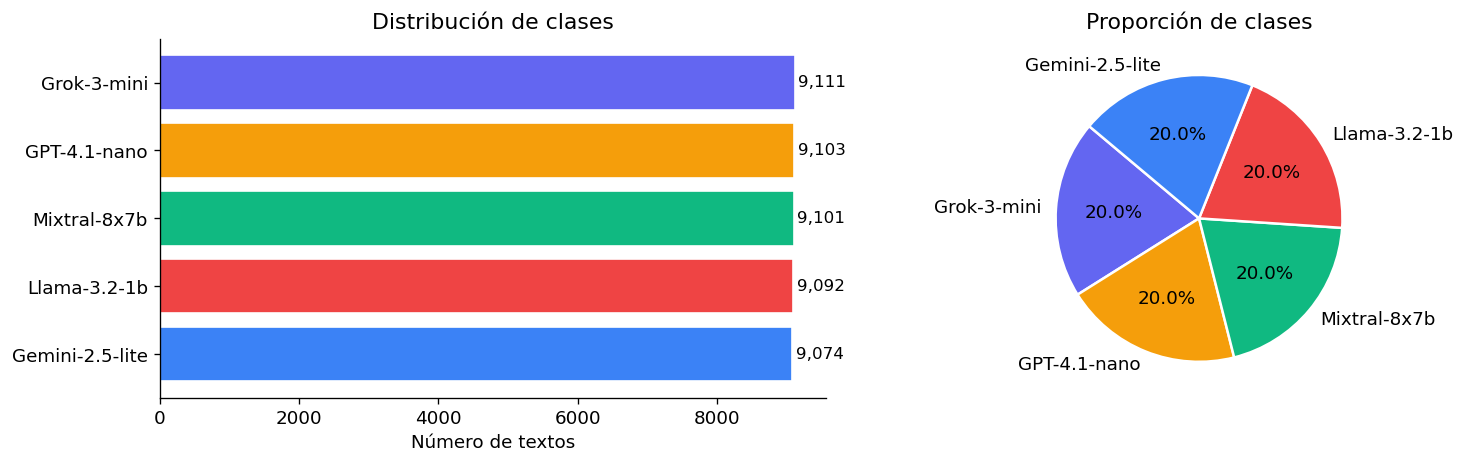

Ratio max/min de clases: 1.00x  ✓ Balanceado


In [3]:
class_counts = df['model'].value_counts()
colors = [MODEL_COLORS[m] for m in class_counts.index]
labels = [MODEL_SHORT[m] for m in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(labels[::-1], class_counts.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('Número de textos')
axes[0].set_title('Distribución de clases')
for i, v in enumerate(class_counts.values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=10)

axes[1].pie(class_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

ratio = class_counts.max() / class_counts.min()
print(f"Ratio max/min de clases: {ratio:.2f}x  {'✓ Balanceado' if ratio < 1.5 else '⚠ Desbalanceado'}")

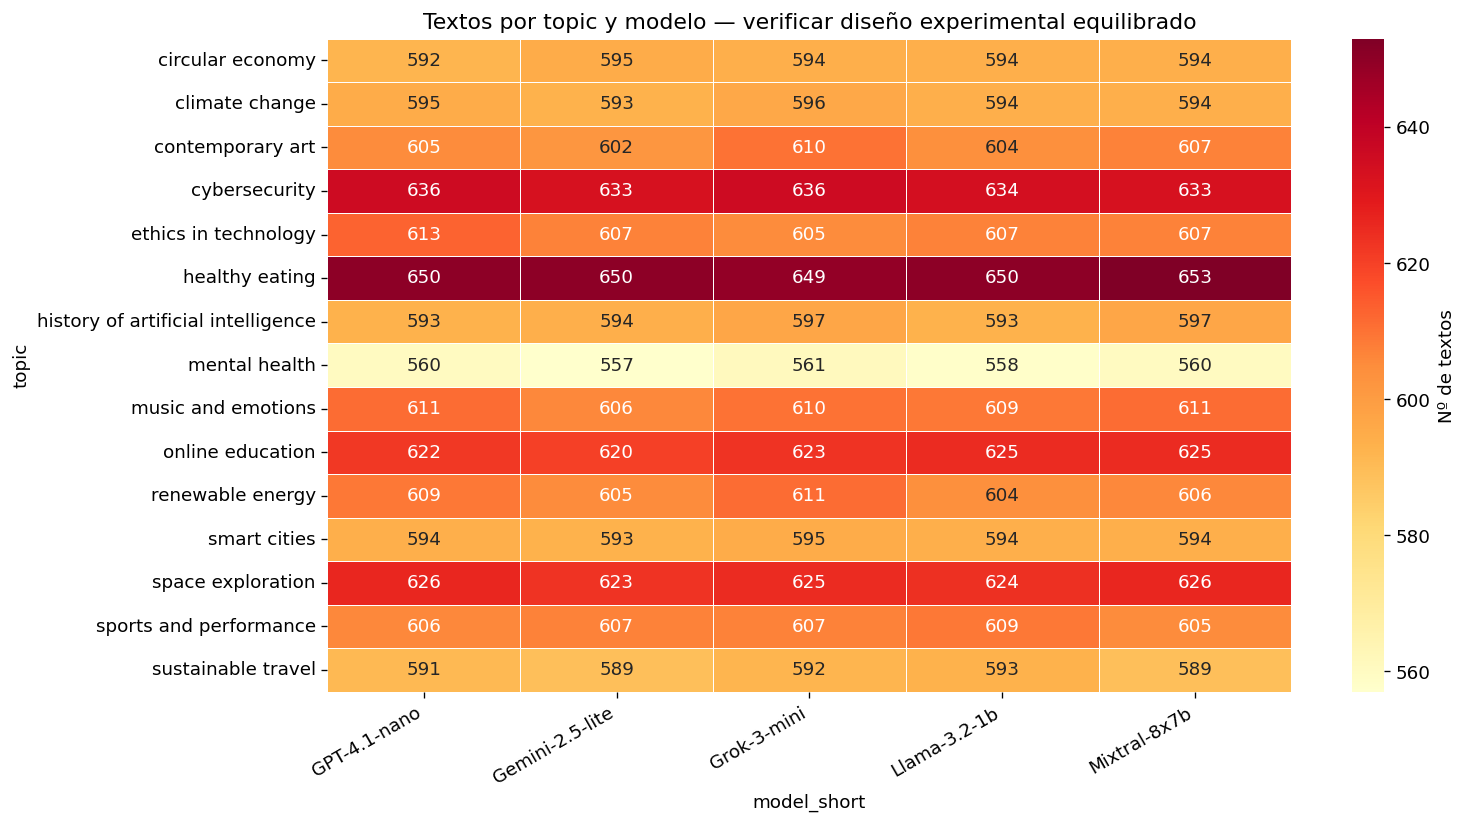

In [4]:
# ── Distribución por topic y modelo ───────────────────────────────────────
# Verifica que el diseño experimental es equilibrado (mismos topics para todos)
pivot_topic = df.groupby(['topic', 'model_short']).size().unstack(fill_value=0)

plt.figure(figsize=(13, 7))
sns.heatmap(pivot_topic, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Nº de textos'})
plt.title('Textos por topic y modelo — verificar diseño experimental equilibrado')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Análisis de Longitud y Tokens

In [5]:
# ── Calcular métricas de longitud ──────────────────────────────────────────
df['char_count']   = df['text'].astype(str).str.len()
df['word_count']   = df['text'].astype(str).str.split().str.len()
df['sent_count']   = df['text'].astype(str).str.count(r'[.!?]+')
df['avg_word_len'] = df['text'].astype(str).apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
)
df['avg_sent_len'] = df['word_count'] / (df['sent_count'].replace(0, 1))

print(df.groupby('model_short')[['word_count', 'avg_sent_len', 'tokens_approx']]
        .mean().round(1).to_string())

                 word_count  avg_sent_len  tokens_approx
model_short                                             
GPT-4.1-nano          288.8          15.9          398.3
Gemini-2.5-lite       373.6          18.5          513.3
Grok-3-mini           424.5          17.5          993.7
Llama-3.2-1b          386.1          18.9          516.2
Mixtral-8x7b          323.2          16.3          462.1


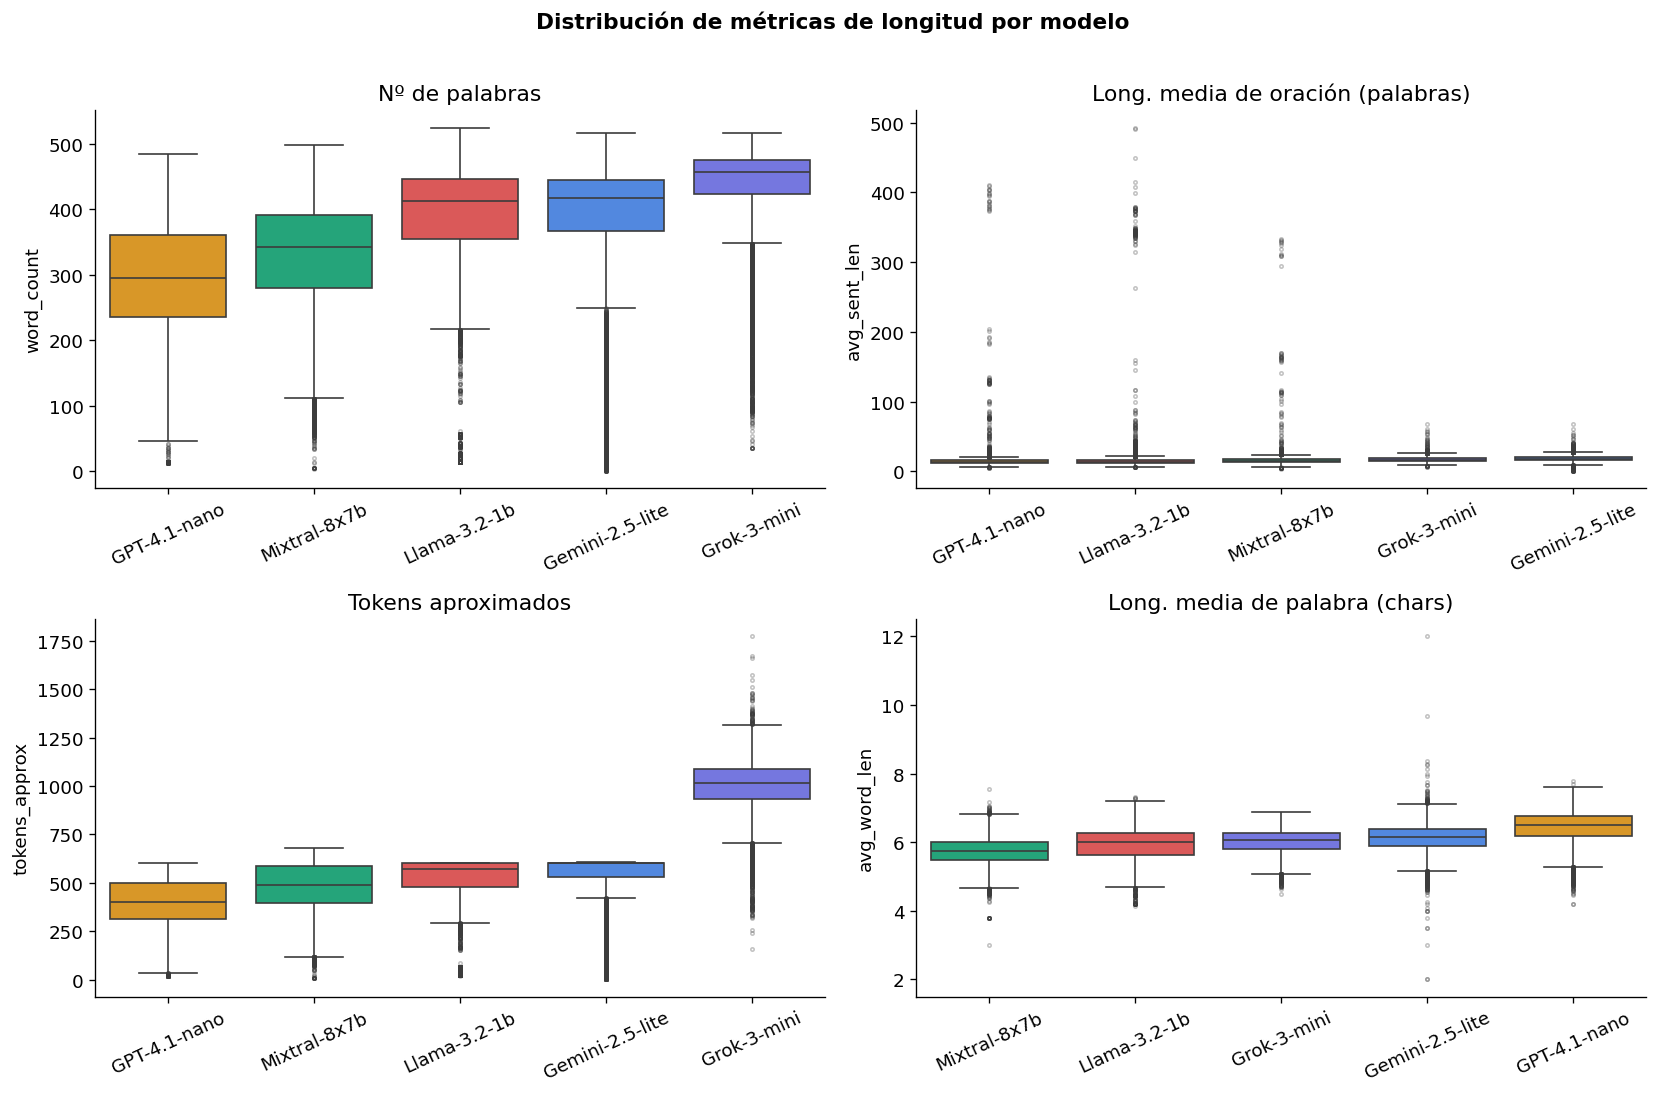

In [6]:
# ── Boxplots de longitud por modelo ───────────────────────────────────────
palette = {m: MODEL_COLORS[k] for k, m in MODEL_SHORT.items()}
metrics = {
    'word_count':    'Nº de palabras',
    'avg_sent_len':  'Long. media de oración (palabras)',
    'tokens_approx': 'Tokens aproximados',
    'avg_word_len':  'Long. media de palabra (chars)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, label) in zip(axes.flatten(), metrics.items()):
    order = df.groupby('model_short')[col].median().sort_values().index
    sns.boxplot(data=df, x='model_short', y=col, order=order, palette=palette,
                flierprops={'markersize': 2, 'alpha': 0.3}, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Distribución de métricas de longitud por modelo', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

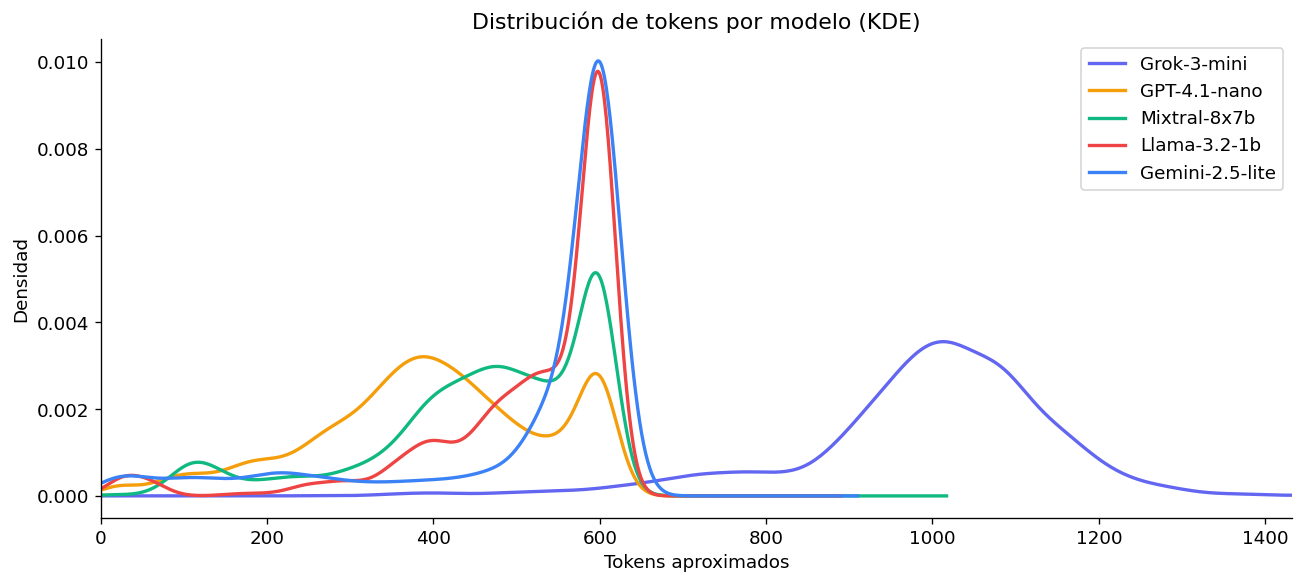

In [7]:
# ── KDE de tokens por modelo ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for model_key, model_label in MODEL_SHORT.items():
    subset = df[df['model'] == model_key]['tokens_approx'].dropna()
    subset.plot.kde(ax=ax, label=model_label,
                    color=MODEL_COLORS[model_key], linewidth=2)
ax.set_xlabel('Tokens aproximados')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de tokens por modelo (KDE)')
ax.set_xlim(0, df['tokens_approx'].quantile(0.99) * 1.2)
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Riqueza Léxica — TTR

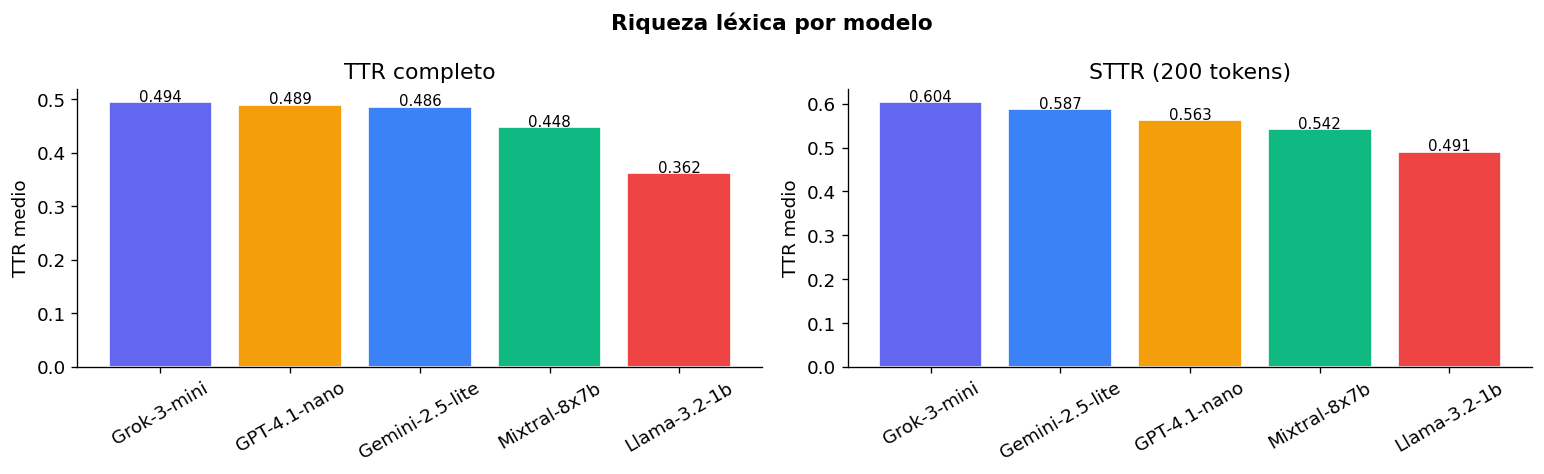

In [8]:
def compute_ttr(text, n=None):
    tokens = str(text).lower().split()
    if n:
        tokens = tokens[:n]
    return len(set(tokens)) / len(tokens) if tokens else 0.0

df['ttr']      = df['text_lemmatized'].apply(compute_ttr)
df['sttr_200'] = df['text_lemmatized'].apply(lambda t: compute_ttr(t, n=200))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette_list = {m: MODEL_COLORS[k] for k, m in MODEL_SHORT.items()}

for ax, col, title in zip(axes, ['ttr', 'sttr_200'], ['TTR completo', 'STTR (200 tokens)']):
    means = df.groupby('model_short')[col].mean().sort_values(ascending=False)
    colors_bar = [palette_list[m] for m in means.index]
    ax.bar(means.index, means.values, color=colors_bar, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('TTR medio')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(means.values):
        ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Riqueza léxica por modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Frecuencia de Palabras y N-gramas
> Se excluyen stopwords en inglés y tags estructurales para ver vocabulario real.

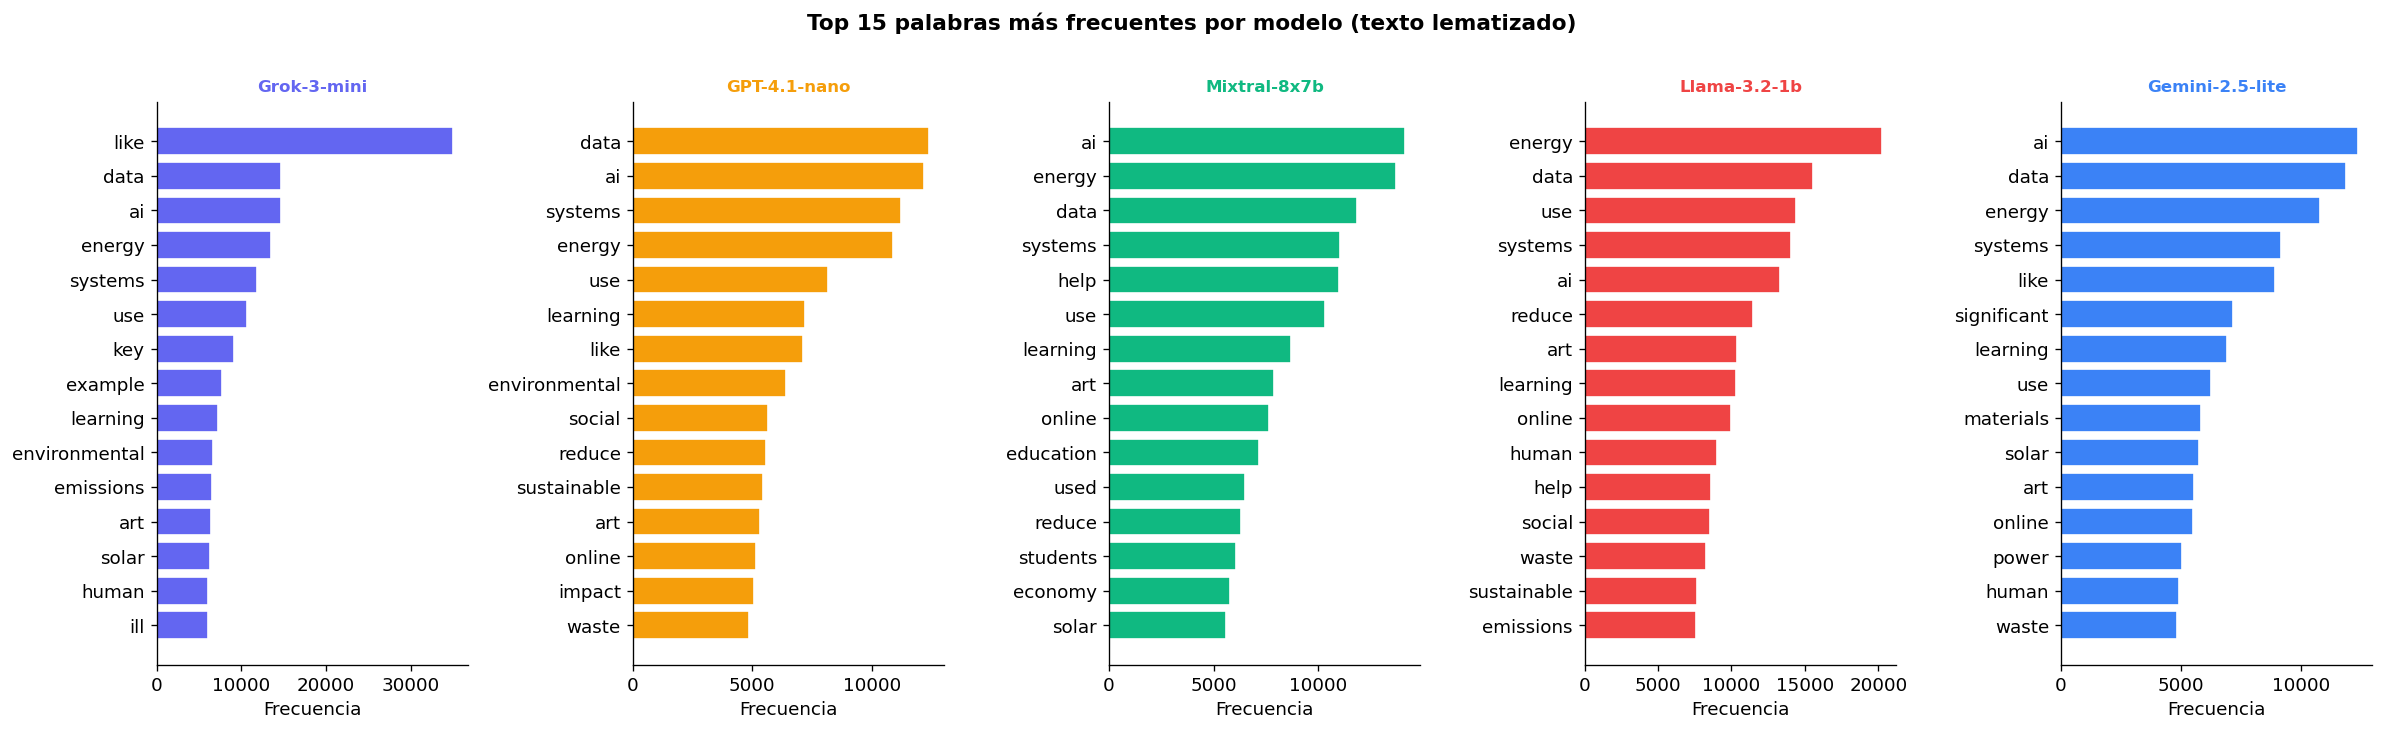

In [9]:
def top_ngrams(corpus, n=1, top_k=20):
    vec = CountVectorizer(
        ngram_range=(n, n),
        max_features=50_000,
        min_df=5,
        stop_words=STOPWORDS_SK,
        token_pattern=r'(?u)\b\w\w+\b'
    )
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return sorted(zip(vocab, counts), key=lambda x: -x[1])[:top_k]

# ── Top 15 unigramas por modelo ────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for ax, (model_key, model_label) in zip(axes, MODEL_SHORT.items()):
    corpus = df[df['model'] == model_key]['text_lemmatized'].dropna().astype(str)
    ngrams = top_ngrams(corpus, n=1, top_k=15)
    words, counts = zip(*ngrams)
    ax.barh(list(words)[::-1], list(counts)[::-1],
            color=MODEL_COLORS[model_key], edgecolor='white')
    ax.set_title(model_label, fontsize=10, fontweight='bold',
                 color=MODEL_COLORS[model_key])
    ax.set_xlabel('Frecuencia')

plt.suptitle('Top 15 palabras más frecuentes por modelo (texto lematizado)',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

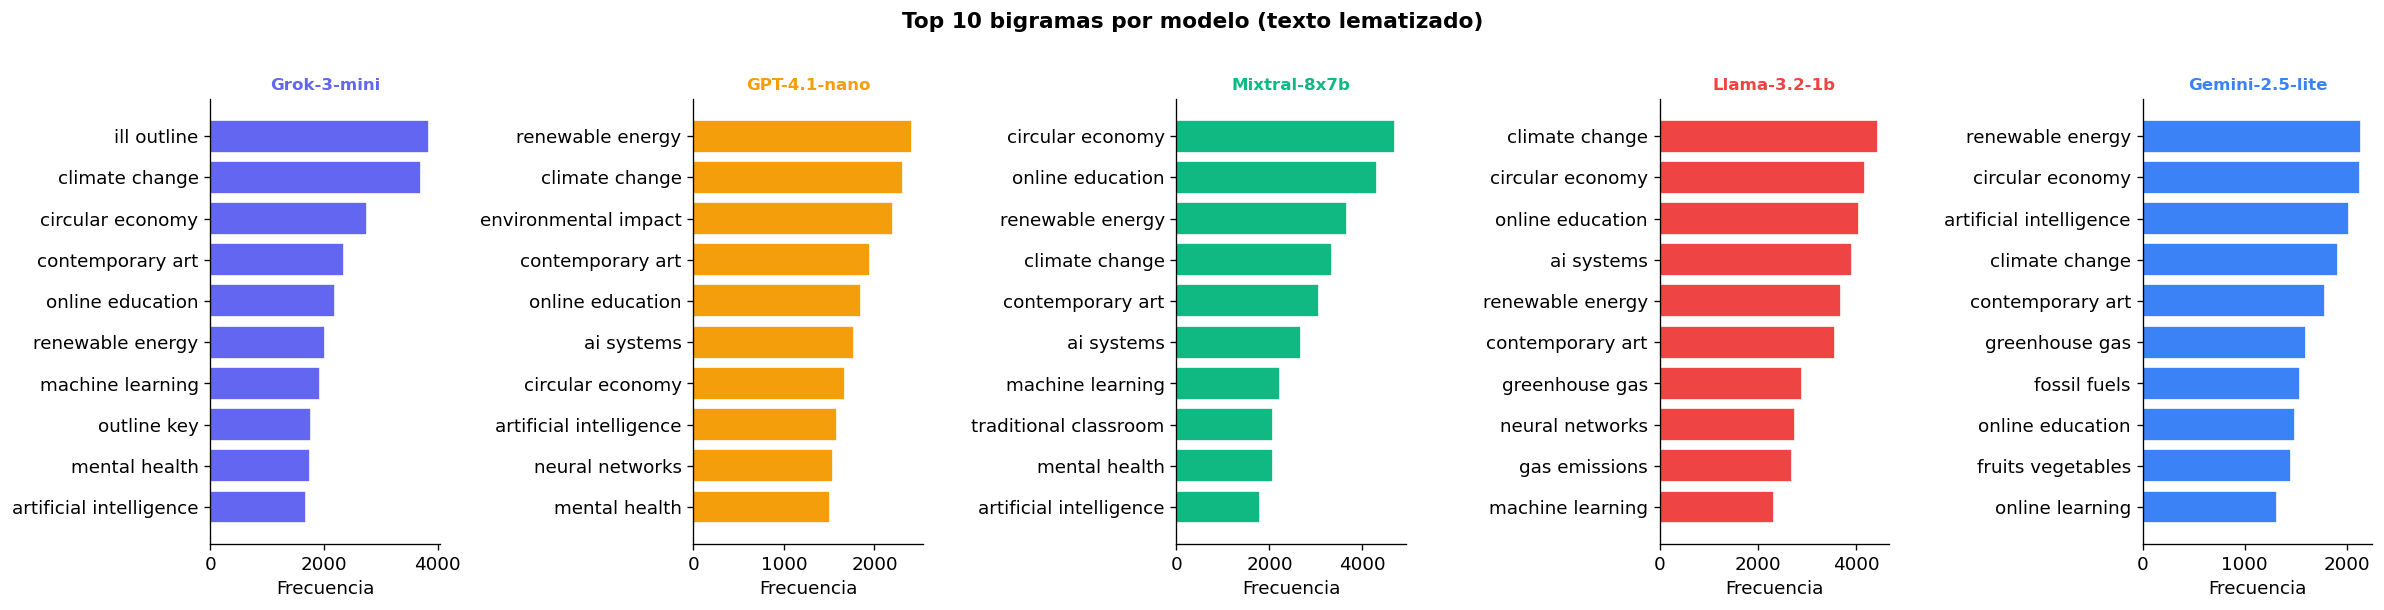

In [10]:
# ── Top 10 bigramas por modelo ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (model_key, model_label) in zip(axes, MODEL_SHORT.items()):
    corpus = df[df['model'] == model_key]['text_lemmatized'].dropna().astype(str)
    ngrams = top_ngrams(corpus, n=2, top_k=10)
    words, counts = zip(*ngrams)
    ax.barh(list(words)[::-1], list(counts)[::-1],
            color=MODEL_COLORS[model_key], edgecolor='white')
    ax.set_title(model_label, fontsize=10, fontweight='bold',
                 color=MODEL_COLORS[model_key])
    ax.set_xlabel('Frecuencia')

plt.suptitle('Top 10 bigramas por modelo (texto lematizado)',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. WordClouds por Modelo

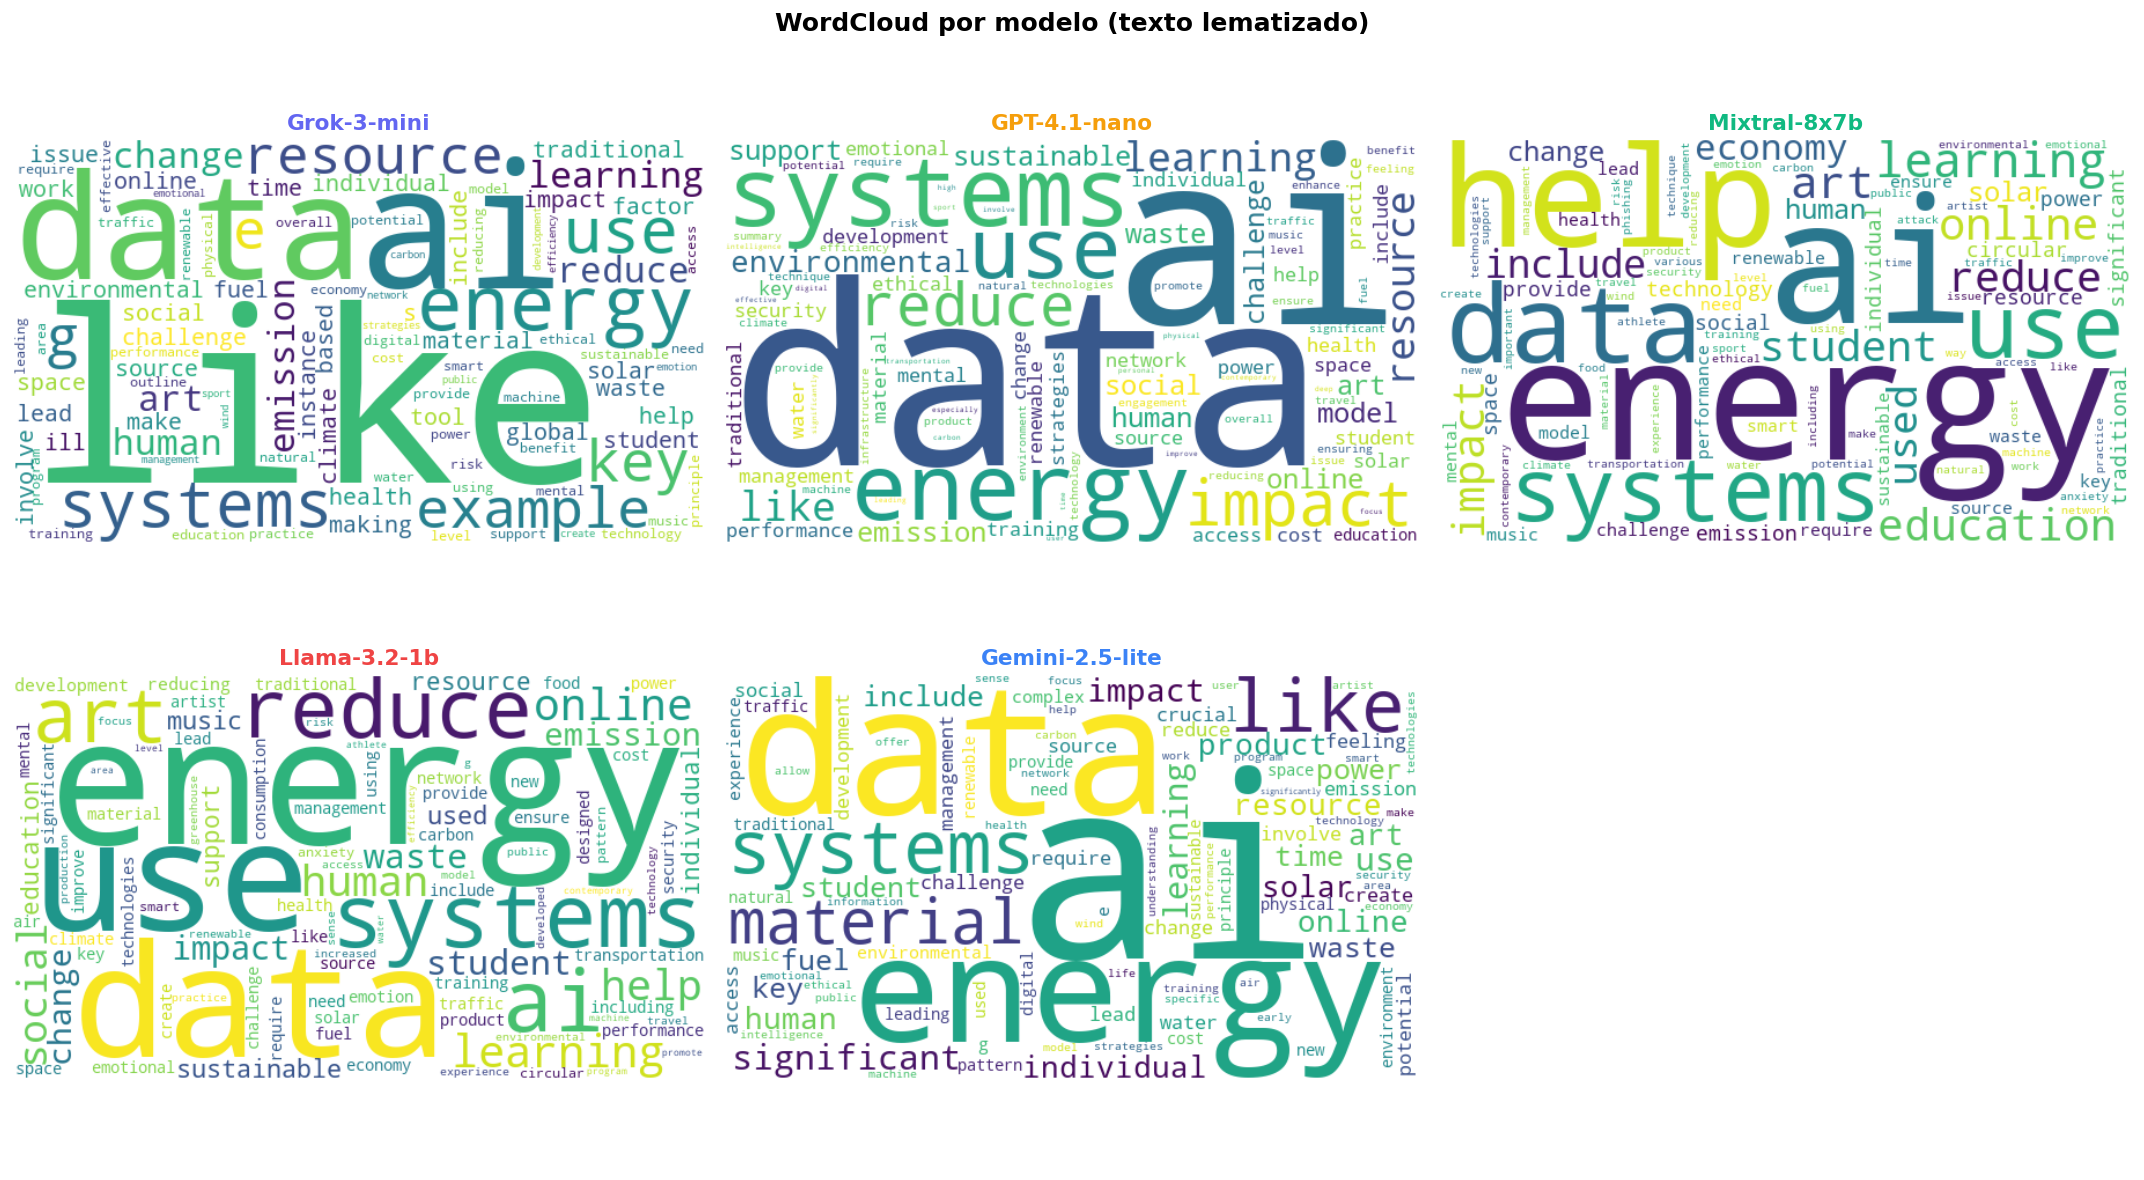

In [11]:
if WORDCLOUD_OK:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, (model_key, model_label) in zip(axes, MODEL_SHORT.items()):
        corpus = ' '.join(
            df[df['model'] == model_key]['text_lemmatized'].dropna().astype(str)
        )
        wc = WordCloud(
            width=600, height=350,
            background_color='white',
            colormap='viridis',
            max_words=100,
            collocations=False,
            stopwords=STOPWORDS_WC,
        ).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(model_label, fontsize=13, fontweight='bold',
                     color=MODEL_COLORS[model_key])

    axes[-1].axis('off')
    plt.suptitle('WordCloud por modelo (texto lematizado)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Instala wordcloud: pip install wordcloud")

---
## 7. Rasgos Estilométricos
> Cuantificación de las huellas identificadas: conectores de discurso y tags estructurales.

Markers descubiertos automáticamente: ['sharing collaboration', 'reducing waste', 'products services', 'cycled production', 'rule based expert', 'based expert', 'use secure', 'consumption patterns', 'closed loop production', 'loop production', 'ai program', 'broadly categorized', 'important note', 'help reduce', 'sure happy', 'll outline', 'outline key', 'll outline key', 'factors like']


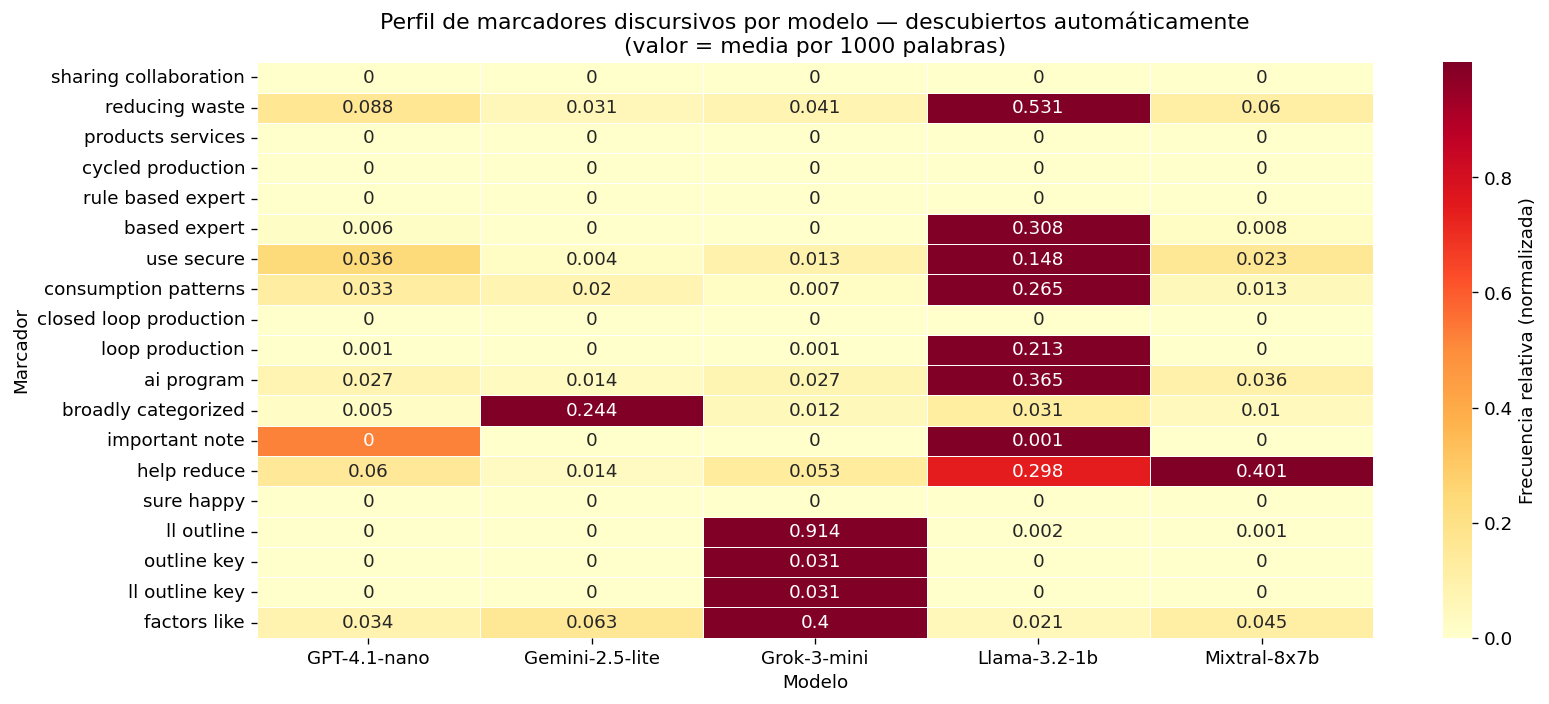

In [12]:
# ── 7.1 Marcadores discursivos — descubiertos automáticamente (one-vs-rest) ─
# Se calculan aquí para usarlos también en el resumen final

def get_discriminative_ngrams(df, text_col='text', label_col='model_short',
                               ngram_range=(1, 3), top_k=15, min_df=50):
    vec = TfidfVectorizer(
        ngram_range=ngram_range, stop_words=STOPWORDS_SK, min_df=min_df,
        max_features=100_000, sublinear_tf=True,
        token_pattern=r'(?u)\b[a-z][a-z]+\b'
    )
    X = vec.fit_transform(df[text_col].astype(str).str.lower())
    feature_names = vec.get_feature_names_out()
    results = {}
    for label in df[label_col].unique():
        mask = (df[label_col] == label).values
        diff = np.asarray(X[mask].mean(axis=0)).flatten() - \
               np.asarray(X[~mask].mean(axis=0)).flatten()
        top_idx = diff.argsort()[::-1][:top_k]
        results[label] = [(feature_names[i], round(diff[i], 4)) for i in top_idx if diff[i] > 0]
    return results

discriminative = get_discriminative_ngrams(df, text_col='text', label_col='model_short')

# Construir los MARKERS automáticamente desde los top resultados
# Nos quedamos solo con los que son bigramas o trigramas (más específicos que unigramas)
AUTO_MARKERS = {}
for model_label, ngrams in discriminative.items():
    for ngram, score in ngrams:
        if len(ngram.split()) > 1:   # solo bigramas y trigramas
            AUTO_MARKERS[ngram] = rf'\b{re.escape(ngram)}\b'

print(f"Markers descubiertos automáticamente: {list(AUTO_MARKERS.keys())}")

# Contar en el texto original
for marker, pattern in AUTO_MARKERS.items():
    col = f'cnt_{marker.replace(" ", "_")}'
    df[col] = df['text'].astype(str).str.lower().str.count(pattern)
    df[f'{col}_norm'] = df[col] / (df['word_count'].replace(0, 1) / 1000)

auto_norm_cols = [f'cnt_{m.replace(" ", "_")}_norm' for m in AUTO_MARKERS]
marker_means = df.groupby('model_short')[auto_norm_cols].mean()
marker_means.columns = list(AUTO_MARKERS.keys())

# Heatmap
marker_norm = marker_means.div(marker_means.max(axis=0) + 1e-9, axis=1)
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(marker_norm.T, annot=marker_means.T.round(3), fmt='g',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Frecuencia relativa (normalizada)'})
ax.set_title('Perfil de marcadores discursivos por modelo — descubiertos automáticamente\n'
             '(valor = media por 1000 palabras)')
ax.set_xlabel('Modelo')
ax.set_ylabel('Marcador')
plt.tight_layout()
plt.show()

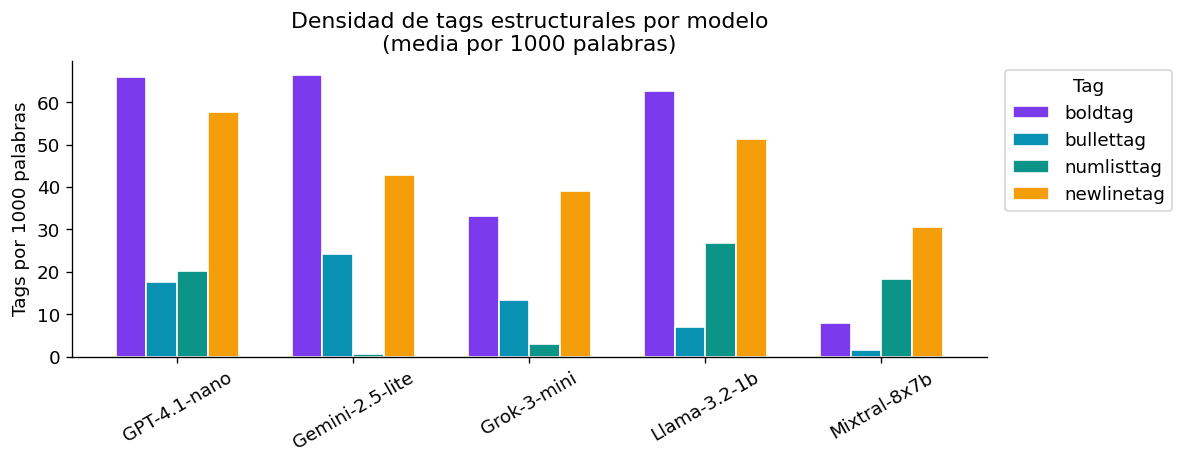

In [13]:
# ── 7.2 Tags estructurales ─────────────────────────────────────────────────
STRUCT_TAGS = ['boldtag', 'bullettag', 'numlisttag', 'newlinetag']

for tag in STRUCT_TAGS:
    df[f'cnt_{tag}'] = df['text_clean'].astype(str).str.lower().str.count(tag)
    df[f'cnt_{tag}_norm'] = df[f'cnt_{tag}'] / (df['word_count'].replace(0, 1) / 1000)

tag_norm_cols = [f'cnt_{t}_norm' for t in STRUCT_TAGS]
tag_means = df.groupby('model_short')[tag_norm_cols].mean()
tag_means.columns = STRUCT_TAGS

fig, ax = plt.subplots(figsize=(10, 4))
tag_means.plot(kind='bar', ax=ax, edgecolor='white', width=0.7,
               color=['#7c3aed', '#0891b2', '#0d9488', '#f59e0b'])
ax.set_title('Densidad de tags estructurales por modelo\n(media por 1000 palabras)')
ax.set_xlabel('')
ax.set_ylabel('Tags por 1000 palabras')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Tag', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

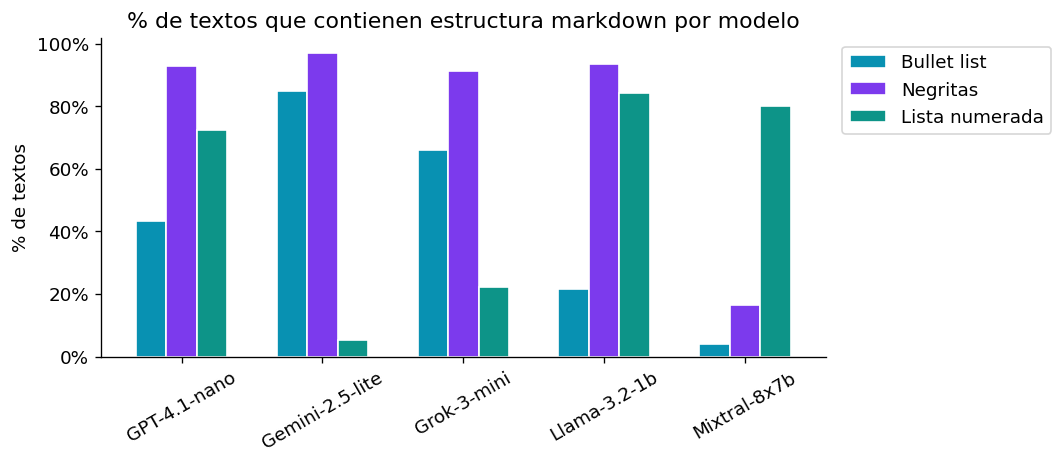

In [14]:
# ── 7.3 % de textos con estructura markdown por modelo ─────────────────────
df['has_bullet']  = (df['cnt_bullettag'] > 0).astype(int)
df['has_bold']    = (df['cnt_boldtag'] > 0).astype(int)
df['has_numlist'] = (df['cnt_numlisttag'] > 0).astype(int)

struct_rates = df.groupby('model_short')[['has_bullet', 'has_bold', 'has_numlist']].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
struct_rates.plot(kind='bar', ax=ax, edgecolor='white', width=0.65,
                  color=['#0891b2', '#7c3aed', '#0d9488'])
ax.set_title('% de textos que contienen estructura markdown por modelo')
ax.set_ylabel('% de textos')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(['Bullet list', 'Negritas', 'Lista numerada'],
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 8. N-gramas Discriminatorios (TF-IDF one-vs-rest)
> En lugar de TF-IDF global (poco útil dado el diseño controlado por topics),
> calculamos qué n-gramas usa **significativamente más** cada modelo respecto al resto.
> Estos son los markers estilísticos reales que usaremos en Feature Engineering.

In [15]:
def get_discriminative_ngrams(df, text_col='text', label_col='model_short',
                               ngram_range=(1, 3), top_k=20, min_df=50):
    """
    Para cada modelo devuelve los n-gramas con mayor diferencia TF-IDF
    respecto al resto (one-vs-rest). Más objetivo que markers manuales.
    """
    vec = TfidfVectorizer(
        ngram_range=ngram_range,
        stop_words=STOPWORDS_SK,
        min_df=min_df,
        max_features=100_000,
        sublinear_tf=True,
        token_pattern=r'(?u)\b[a-z][a-z]+\b'
    )
    X = vec.fit_transform(df[text_col].astype(str).str.lower())
    feature_names = vec.get_feature_names_out()
    labels = df[label_col].unique()

    results = {}
    for label in labels:
        mask = (df[label_col] == label).values
        mean_target = np.asarray(X[mask].mean(axis=0)).flatten()
        mean_rest   = np.asarray(X[~mask].mean(axis=0)).flatten()
        diff_score  = mean_target - mean_rest
        top_idx     = diff_score.argsort()[::-1][:top_k]
        results[label] = [
            (feature_names[i], round(diff_score[i], 4), round(mean_target[i], 4))
            for i in top_idx if diff_score[i] > 0
        ]
    return results

discriminative = get_discriminative_ngrams(
    df, text_col='text', label_col='model_short',
    ngram_range=(1, 3), top_k=20, min_df=50
)

print("=== Top n-gramas discriminatorios por modelo (score = diff TF-IDF one-vs-rest) ===\n")
for model, ngrams in discriminative.items():
    print(f"── {model} ──")
    for ngram, diff, mean in ngrams[:15]:
        print(f"  {ngram:40s}  diff={diff:.4f}  mean={mean:.4f}")
    print()

=== Top n-gramas discriminatorios por modelo (score = diff TF-IDF one-vs-rest) ===

── GPT-4.1-nano ──
  summary                                   diff=0.0096  mean=0.0114
  ensuring                                  diff=0.0046  mean=0.0087
  technological                             diff=0.0046  mean=0.0081
  especially                                diff=0.0041  mean=0.0079
  enhance                                   diff=0.0040  mean=0.0074
  engagement                                diff=0.0040  mean=0.0085
  environmental                             diff=0.0039  mean=0.0122
  models                                    diff=0.0039  mean=0.0086
  sustainable                               diff=0.0038  mean=0.0111
  practices                                 diff=0.0035  mean=0.0092
  enhances                                  diff=0.0034  mean=0.0044
  resource                                  diff=0.0034  mean=0.0083
  combining                                 diff=0.0032  mean=0.0041


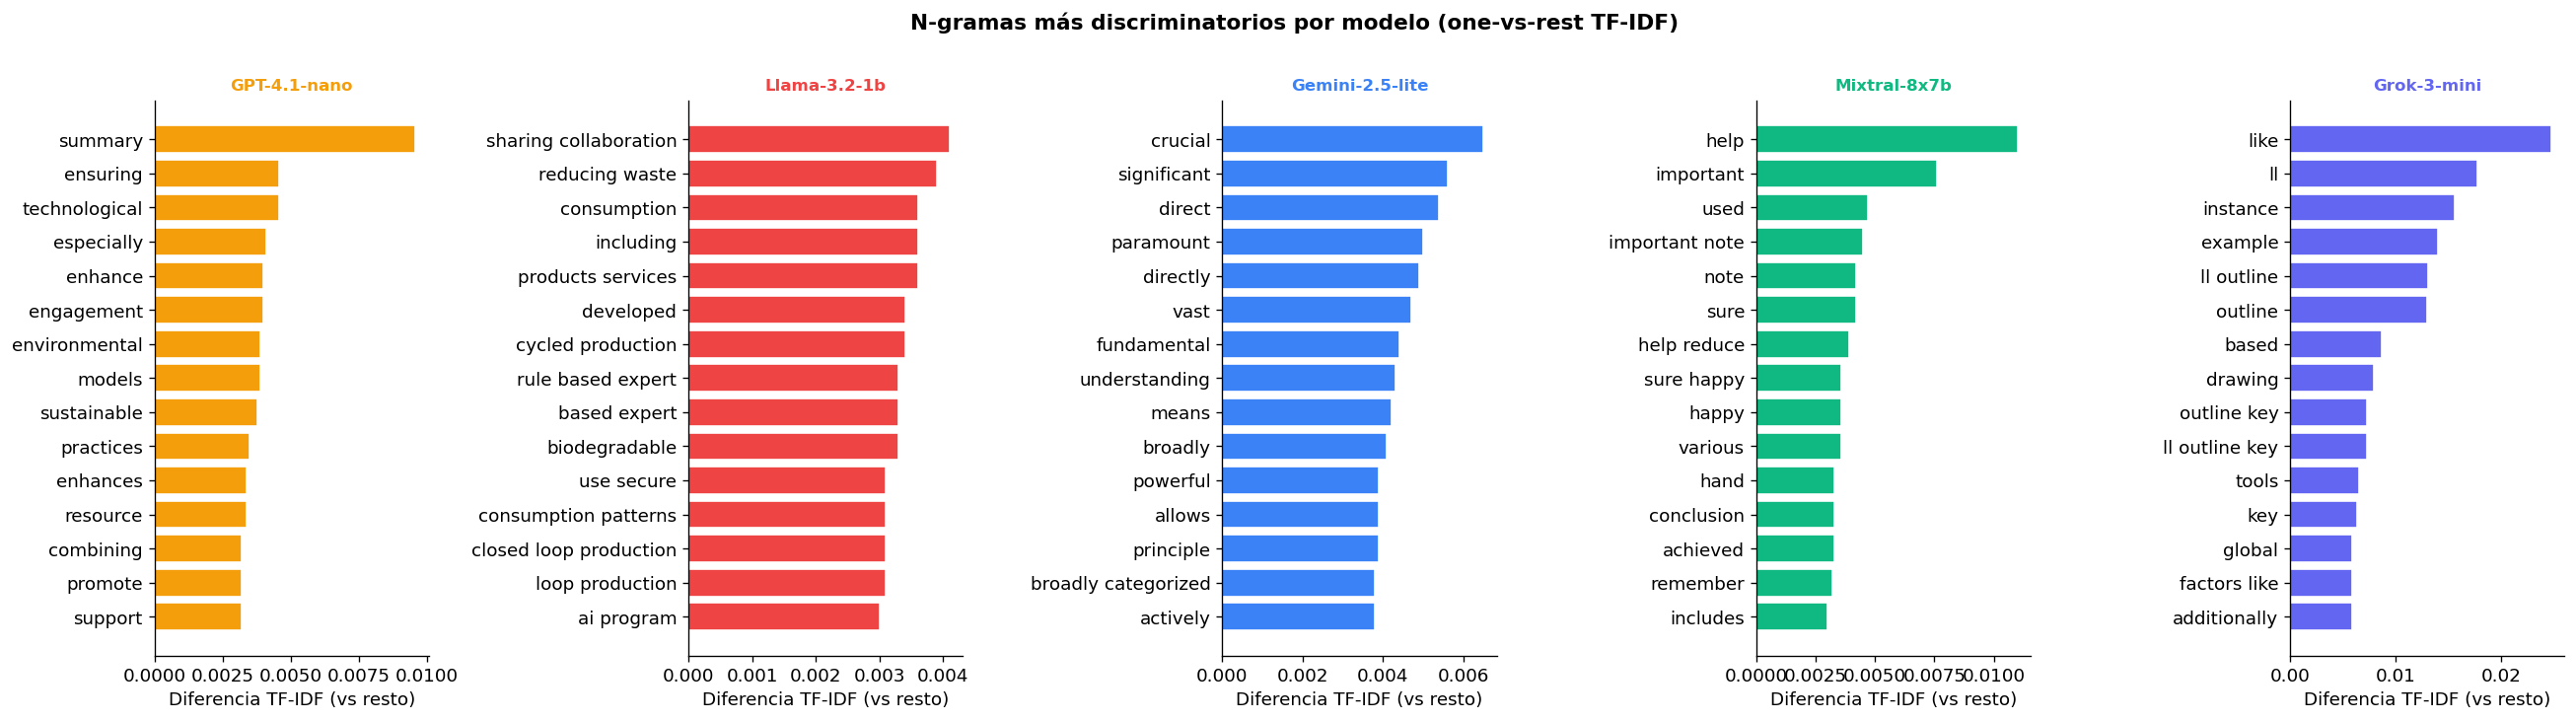

In [16]:
# ── Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
for ax, (model_label, ngrams) in zip(axes, discriminative.items()):
    terms, diffs, _ = zip(*ngrams[:15])
    color = [v for k, v in MODEL_COLORS.items() if MODEL_SHORT[k] == model_label][0]
    ax.barh(list(terms)[::-1], list(diffs)[::-1], color=color, edgecolor='white')
    ax.set_title(model_label, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Diferencia TF-IDF (vs resto)')

plt.suptitle('N-gramas más discriminatorios por modelo (one-vs-rest TF-IDF)',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Reducción Dimensional — LSA 2D
> Visualiza si los 5 modelos son separables en el espacio TF-IDF.

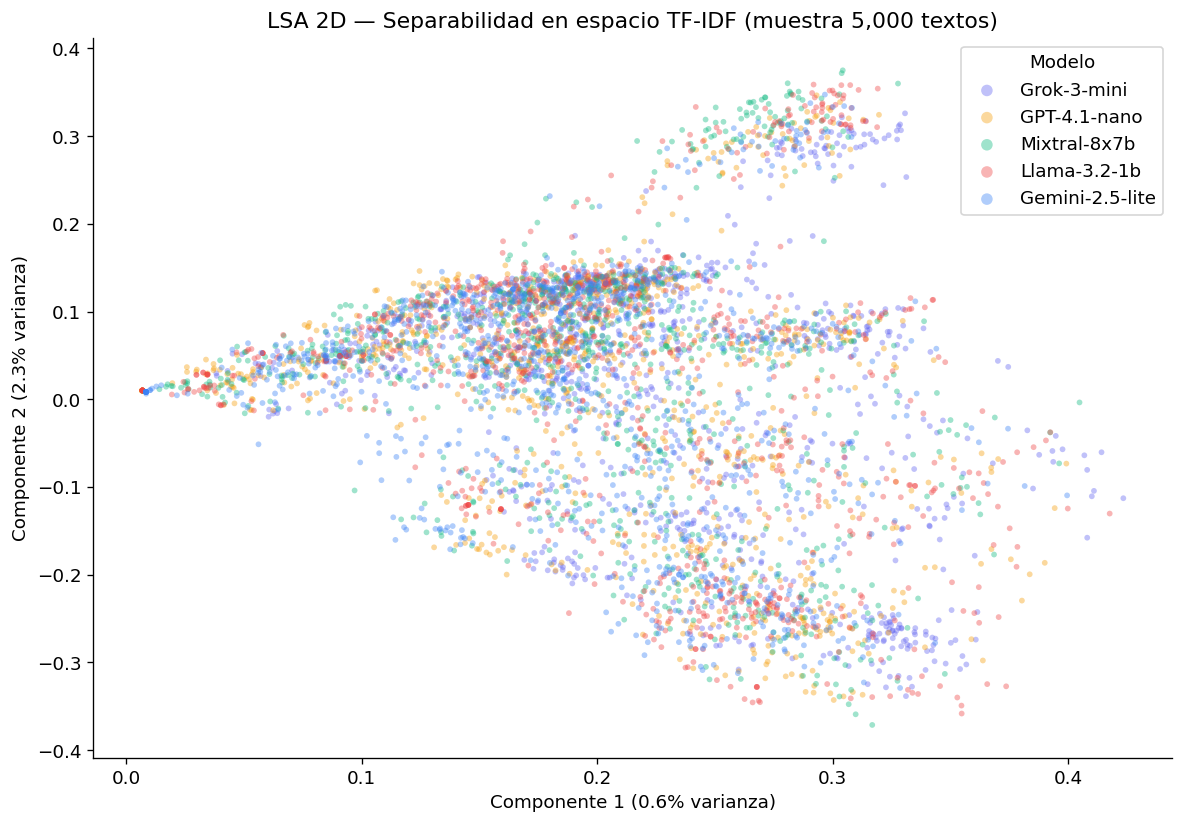

Varianza explicada total: 2.9%


In [17]:
SAMPLE_N = 5000
df_sample = df.sample(min(SAMPLE_N, len(df)), random_state=42)

vec_lsa = TfidfVectorizer(max_features=10_000, sublinear_tf=True,
                           min_df=5, stop_words=STOPWORDS_SK)
X_tfidf = vec_lsa.fit_transform(
    df_sample['text_lemmatized'].fillna('').astype(str)
)

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

df_sample = df_sample.copy()
df_sample['lsa_x'] = X_2d[:, 0]
df_sample['lsa_y'] = X_2d[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for model_key, model_label in MODEL_SHORT.items():
    mask = df_sample['model'] == model_key
    ax.scatter(df_sample.loc[mask, 'lsa_x'], df_sample.loc[mask, 'lsa_y'],
               c=MODEL_COLORS[model_key], label=model_label,
               alpha=0.4, s=12, edgecolors='none')

ax.set_title(f'LSA 2D — Separabilidad en espacio TF-IDF (muestra {SAMPLE_N:,} textos)')
ax.set_xlabel(f'Componente 1 ({svd.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'Componente 2 ({svd.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.legend(markerscale=2, title='Modelo')
plt.tight_layout()
plt.show()

print(f"Varianza explicada total: {svd.explained_variance_ratio_.sum()*100:.1f}%")

---
## 10. Resumen de Fingerprints por Modelo

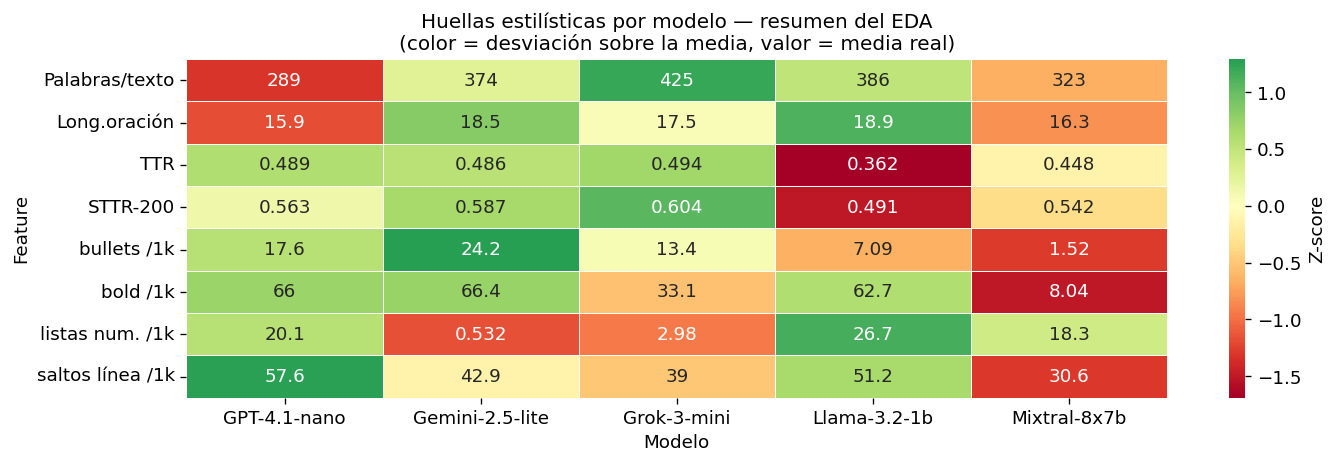


Tabla de valores medios:
                 Palabras/texto  Long.oración    TTR  STTR-200  bullets /1k  bold /1k  listas num. /1k  saltos línea /1k
model_short                                                                                                             
GPT-4.1-nano            288.752        15.857  0.489     0.563       17.639    65.990           20.127            57.617
Gemini-2.5-lite         373.571        18.504  0.486     0.587       24.203    66.412            0.532            42.941
Grok-3-mini             424.540        17.491  0.494     0.604       13.417    33.073            2.977            38.981
Llama-3.2-1b            386.057        18.877  0.362     0.491        7.091    62.654           26.749            51.236
Mixtral-8x7b            323.235        16.334  0.448     0.542        1.520     8.045           18.274            30.642


In [21]:
resumen_cols = [
    'word_count', 'avg_sent_len',
    'ttr', 'sttr_200',
    'cnt_bullettag_norm', 'cnt_boldtag_norm',
    'cnt_numlisttag_norm', 'cnt_newlinetag_norm',
]

resumen = df.groupby('model_short')[resumen_cols].mean().round(3)
resumen.columns = [
    'Palabras/texto', 'Long.oración',
    'TTR', 'STTR-200',
    'bullets /1k', 'bold /1k',
    'listas num. /1k', 'saltos línea /1k',
]

resumen_norm = (resumen - resumen.mean()) / (resumen.std() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(resumen_norm.T, annot=resumen.T, fmt='.3g',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Z-score'})
ax.set_title('Huellas estilísticas por modelo — resumen del EDA\n'
             '(color = desviación sobre la media, valor = media real)', fontsize=12)
ax.set_xlabel('Modelo')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTabla de valores medios:")
print(resumen.to_string())

In [22]:
# ── Exportar features para Fase 2 ─────────────────────────────────────────
# Excluidos:
#   - expansion_ratio: requiere la pregunta original, no computable en inferencia
#   - tokens_approx: redundante con word_count
#   - norm_cols (markers manuales): sustituidos por análisis automático one-vs-rest

feature_cols = [
    'iteration', 'topic', 'seed_model', 'model', 'model_short',
    'word_count', 'char_count', 'sent_count', 'avg_word_len', 'avg_sent_len',
    'ttr', 'sttr_200',
    'has_bullet', 'has_bold', 'has_numlist',
] + tag_norm_cols

df[feature_cols].to_csv('../datasets/features_eda.csv', index=False)
print(f"Features guardadas → '../datasets/features_eda.csv'")
print(f"Shape: {df[feature_cols].shape} ({len(feature_cols)} columnas)")

Features guardadas → '../datasets/features_eda.csv'
Shape: (45481, 19) (19 columnas)


---
## 11. Conclusiones del EDA

### Hallazgos principales

| Dimensión | Modelo destacado | Observación |
|-----------|-----------------|-------------|
| Longitud de texto | Grok-3-mini | Textos más largos (425 palabras de media) |
| Riqueza léxica (TTR) | Grok-3-mini | Mayor variedad de vocabulario (0.604 STTR) |
| Riqueza léxica (TTR) | Llama-3.2-1b | TTR más bajo (0.362) — vocabulario repetitivo |
| Tags estructurales (bold) | GPT-4.1-nano + Gemini | Alta densidad de negritas (>65/1k) |
| Tags estructurales (bullet) | Gemini-2.5-lite | Mayor uso de listas bullet (24.2/1k) |
| Tags estructurales (numlist) | Llama-3.2-1b | Más listas numeradas (26.7/1k) |
| Menos formateado | Mixtral-8x7b | Bold (8/1k) y bullets (1.5/1k) muy bajos |
| Contracción post-lema | Grok-3-mini | `ll outline`, `ll outline key` — únicos de este modelo |
| Vocabulario enfático | Gemini-2.5-lite | `crucial`, `significant`, `paramount`, `broadly categorized` |
| Tono asistente | Mixtral-8x7b | `sure happy`, `important note`, `help reduce` |
| Repetición temática | Llama-3.2-1b | Reutiliza literalmente frases del enunciado (`reducing waste`, `consumption patterns`) |
| Perfil equilibrado | GPT-4.1-nano | Sin rasgos extremos — el más difícil de clasificar |

### Decisiones de diseño para Feature Engineering
- **Ratio de expansión descartado**: requiere conocer la pregunta original, no computable en inferencia.
- **tokens_approx descartado**: redundante con `word_count`.
- **TF-IDF global descartado**: el diseño controlado por 15 topics hace que el vocabulario temático sea compartido entre modelos — no discrimina estilo.
- **Markers manuales descartados**: sustituidos por descubrimiento automático one-vs-rest, más objetivo y sin sesgo de selección.
- **Features a usar en Fase 2**: longitud, TTR/STTR, tags estructurales normalizados, n-gramas discriminatorios del análisis one-vs-rest.

### Separabilidad esperada
- **Más fáciles de separar**: Grok-3-mini (contracciones post-lema únicas) y Mixtral-8x7b (ausencia de formato + tono asistente).
- **Más difíciles**: GPT-4.1-nano vs Gemini-2.5-lite — perfil de formato similar y sin rasgos extremos claros.

### Próximo paso
→ **Fase 2:** Feature Engineering — construir el vector de features estilométricas para entrenar los clasificadores ML.